In [ ]:
# The original XGBoost model evaluated in previous notebook used lag and rolling target-related features calculated from actual historical sales. 
# This is a simplied approach, as in real 42-day forecasting scenario future sales values are unknown.

# Therefore, in this section, recursive forecasting is implemented to simulate real-world sales/demand forecasting scenario

# Alternative (and often considered as a better) approach is to use direct forecasting, in which we train separate model for each specific time step in the forecast horizon. 
# While, it avoids error accumulation that appears in recursive forecasting approach, it has significantly higher computation cost. 
# That's why recursive forecasting was implemented in this project as a simpler production-oriented simulation.

## 01. Importing libraries, loading the model & evaluation functions

In [1]:
# importing the core libraries and adjusting the settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from xgboost import XGBRegressor as XGB
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# setting style for visualizations
sns.set_theme(style="darkgrid")

# limiting scientific notation
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
# loading the final dataset prepared for modeling
df_model = pd.read_csv("../01_data/03_modeling/rossmann_dataset_for_modeling_final.csv") 

# minor data types adjustment
df_model["Date"] = pd.to_datetime(df_model["Date"])
cat_cols = ['Store', 'StoreType', 'Assortment', 'DayOfWeek', 'week_of_month', 'month_of_year', 'quarter_of_year', 'assigned_land']
df_model[cat_cols] = df_model[cat_cols].astype("category")

In [5]:
# loading the final XGBoost model
import joblib
final_model = joblib.load("../03_models/xgboost_tuned_v1.pkl")

In [30]:
# train set 
train_df = df_model[df_model["Date"] < "2015-06-19"] 

# test set 
test_df = df_model[df_model["Date"] >= "2015-06-19"] 

print(f"Start date for the training set: {train_df["Date"].min()}")
print(f"End date for the training set: {train_df["Date"].max()}")
print("--------------------------------------------------------")
print(f"Start date for the testing set: {test_df["Date"].min()}")
print(f"End date for the testing set: {test_df["Date"].max()}")

Start date for the training set: 2013-01-01 00:00:00
End date for the training set: 2015-06-18 00:00:00
--------------------------------------------------------
Start date for the testing set: 2015-06-19 00:00:00
End date for the testing set: 2015-07-31 00:00:00


In [31]:
### FUNCTIONS FOR MODEL EVALUATION ### 

# help function for rmspe calculation

from sklearn.metrics import make_scorer

def rmspe_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    mask = y_true != 0

    return np.sqrt(
        np.mean(
            ((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2
        )
    )

rmspe_scorer = make_scorer(
    rmspe_log,
    greater_is_better=False
)

# function for all metrics calculation

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def calculate_metrics(y_true_log, y_pred_log):

    y_pred_log = pd.Series(y_pred_log, index=y_true_log.index) # converting to Series if needed

    valid = y_true_log.notna() & y_pred_log.notna() # handling missing values

    # back transformation to original Sales scale
    y_true = np.expm1(y_true_log[valid])
    y_pred = np.expm1(y_pred_log[valid])
    
    # metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = y_true != 0
    rmspe = np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

    return {
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse,
        "RMSPE": rmspe
    }

# function for model evaluation

def evaluate_model(y_true_log, y_pred_log, model_name):

    metrics = calculate_metrics(
        y_true_log,
        y_pred_log
    )

    return pd.DataFrame({
        "Model": [model_name],
        "R2": [metrics["R2"]],
        "MAE": [metrics["MAE"]],
        "RMSE": [metrics["RMSE"]],
        "RMSPE": [metrics["RMSPE"]]
    })

In [32]:
# model features 

model_features = list(final_model.named_steps["preprocessor"].feature_names_in_)
model_features

['Promo_Duration_Days',
 'Promo2_Duration_Days',
 'Competition_Existence_Days',
 'CompetitionDistance_v2',
 'Sales_log_lag_1',
 'Sales_log_rolling_mean_14',
 'Promo',
 'Promo_Start',
 'Promo_Start_Tomorrow',
 'Promo_End',
 'Promo_End_Yesterday',
 'Promo2_Active',
 'Promo2Renewal',
 'Competition_Exists',
 'is_month_begin',
 'is_month_end',
 'open_closed_tomorrow',
 'open_closed_yesterday',
 'Hol_Any',
 'Hol_Christmas_1w',
 'Hol_Christmas_2w',
 'Hol_Christmas_3w',
 'Hol_Easter_1w',
 'Hol_Easter_2w',
 'Hol_Easter_3w',
 'Hol_Special_Event',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'DayOfWeek',
 'week_of_month',
 'month_of_year',
 'quarter_of_year',
 'assigned_land']

In [33]:
# One-step forecasting results (results for the original XGBoost from previous notebook)

X_test_one_step = test_df[model_features]
y_test = test_df["Sales_log"]

y_pred_one_step = final_model.predict(X_test_one_step)

results_one_step = evaluate_model(
    y_test,
    y_pred_one_step,
    "XGBoost One-step Forecast"
)

results_one_step

,Model,R2,MAE,RMSE,RMSPE
0,XGBoost One-step Forecast,0.9160,606.9590,882.3426,0.1205


## 02. Defining Recursive Forecasting Setup 

In [52]:
### RECURSIVE FORECASTING SIMULATION FUNTION ###

def recursive_forecast_store_level(model,
                                   train_df,
                                   test_df,
                                   model_features,
                                   target_col="Sales_log",
                                   store_col="Store",
                                   date_col="Date"):
    
    train_df = train_df.sort_values([store_col, date_col]).copy()
    test_df = test_df.sort_values([date_col, store_col]).copy()

    # sales history per store, initialized with actual train values
    sales_history = {
        store: list(group[target_col].values)
        for store, group in train_df.groupby(store_col, observed=False)
    }

    predictions = []

    for current_date in sorted(test_df[date_col].unique()):

        current_rows = test_df[test_df[date_col] == current_date].copy()

        # update lag/rolling features using available history
        for idx, row in current_rows.iterrows():

            store = row[store_col]
            history = sales_history[store]

            # recursive lag features
            if "Sales_log_lag_1" in model_features:
                current_rows.loc[idx, "Sales_log_lag_1"] = history[-1]
                current_rows.loc[idx, "Sales_log_lag_1_recursive_used"] = history[-1]
            # if "Sales_log_lag_7" in model_features:
            #     current_rows.loc[idx, "Sales_log_lag_7"] = history[-7] if len(history) >= 7 else np.nan
            # if "Sales_log_lag_14" in model_features:
            #     current_rows.loc[idx, "Sales_log_lag_14"] = history[-14] if len(history) >= 14 else np.nan
            # if "Sales_log_lag_28" in model_features:
            #     current_rows.loc[idx, "Sales_log_lag_28"] = history[-28] if len(history) >= 28 else np.nan

            # recursive rolling features
            # if "Sales_log_rolling_mean_7" in model_features:
            #     current_rows.loc[idx, "Sales_log_rolling_mean_7"] = np.mean(history[-7:]) if len(history) >= 7 else np.nan
            if "Sales_log_rolling_mean_14" in model_features:
                current_rows.loc[idx, "Sales_log_rolling_mean_14"] = np.mean(history[-14:]) if len(history) >= 14 else np.nan
                current_rows.loc[idx, "Sales_log_rolling_mean_14_recursive_used"] = np.mean(history[-14:]) if len(history) >= 14 else np.nan
            # if "Sales_log_rolling_mean_28" in model_features:
            #     current_rows.loc[idx, "Sales_log_rolling_mean_28"] = np.mean(history[-28:]) if len(history) >= 28 else np.nan


        # predicting current day
        X_current = current_rows[model_features]
        y_pred_current = model.predict(X_current)

        current_rows["Sales_log_pred_recursive"] = y_pred_current

        predictions.append(current_rows[[store_col, date_col, "Sales_log_pred_recursive",
                                         "Sales_log_lag_1_recursive_used",
                                         "Sales_log_rolling_mean_14_recursive_used"]])

         # update store history after predicting all stores for the current date
        for store, pred in zip(current_rows[store_col], y_pred_current):
            sales_history[store].append(pred)

    predictions_df = pd.concat(predictions, ignore_index=True)

    return predictions_df

## 03. Recursive Forecasting Results & Comparision with Original XGBoost

In [53]:
# generating recursive forecast

recursive_predictions = recursive_forecast_store_level(model=final_model,
                                                       train_df=train_df,
                                                       test_df=test_df,
                                                       model_features=model_features
                                                       )

recursive_predictions = recursive_predictions.merge(
    test_df[["Store", "Date", "Sales_log", "Sales_log_lag_1", "Sales_log_rolling_mean_14"]],
    on=["Store", "Date"],
    how="left")

/var/folders/mq/ckpznt291nn2xj9_5lp2btvw0000gn/T/ipykernel_3762/2745444436.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.778171881033469' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  current_rows.loc[idx, "Sales_log_lag_1_recursive_used"] = history[-1]
/var/folders/mq/ckpznt291nn2xj9_5lp2btvw0000gn/T/ipykernel_3762/2745444436.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.963262577462524' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  current_rows.loc[idx, "Sales_log_rolling_mean_14_recursive_used"] = np.mean(history[-14:]) if len(history) >= 14 else np.nan
/var/folders/mq/ckpznt291nn2xj9_5lp2btvw0000gn/T/ipykernel_3762/2745444436.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise

In [ ]:
# sanity check for Store = 1 whether our Recursive Forecasting Algorithm works well
recursive_predictions[recursive_predictions["Store"].astype(int) == 1][
    [
        "Date",
        "Sales_log",
        "Sales_log_lag_1",
        "Sales_log_lag_1_recursive_used",
        "Sales_log_pred_recursive",
        "Sales_log_rolling_mean_14",
        "Sales_log_rolling_mean_14_recursive_used"
    ]
].head(10)

,Date,Sales_log,Sales_log_lag_1,Sales_log_lag_1_recursive_used,Sales_log_pred_recursive,Sales_log_rolling_mean_14,Sales_log_rolling_mean_14_recursive_used
0,2015-06-19,8.3436,8.4438,8.4438,8.5058,8.4020,8.4020
1114,2015-06-20,8.3183,8.3436,8.5058,8.2640,8.3834,8.3950
2260,2015-06-22,8.2550,8.3183,8.2640,8.2903,8.3585,8.3662
3374,2015-06-23,8.2330,8.2550,8.2903,8.2168,8.3345,8.3447
4488,2015-06-24,8.1158,8.2330,8.2168,8.1856,8.3269,8.3360
5602,2015-06-25,8.1702,8.1158,8.1856,8.1723,8.3129,8.3270
6716,2015-06-26,8.1071,8.1702,8.1723,8.2368,8.3022,8.3165
7831,2015-06-27,8.2990,8.1071,8.2368,8.2268,8.2966,8.3200
8978,2015-06-29,8.5560,8.2990,8.2268,8.8661,8.3039,8.3222
10093,2015-06-30,8.6545,8.5560,8.8661,8.7422,8.3283,8.3687


In [66]:
# It looks good. 
# e.g., for 2015-06-23 when Sales_log = 8.2330, Sales_log_lag_1 = 8.2550 (which is Sales_log for 2015-06-22)
# and for 2015-06-23 when Sales_log_pred_recursive = 8.2168, Sales_log_lag_1_recursive_used = 8.2903 (which is Sales_log_pred_recursive for 2015-06-22)

In [ ]:
# one-step forecasting results using original lag/rolling features

y_pred_one_step = final_model.predict(test_df[model_features])

results_one_step = evaluate_model(
    test_df["Sales_log"],
    y_pred_one_step,
    "XGBoost One-Step Forecast")

In [68]:
# recursive forecasting results 

results_recursive = evaluate_model(
    recursive_predictions["Sales_log"],
    recursive_predictions["Sales_log_pred_recursive"],
    "XGBoost Recursive Forecast")

# comparison of recursive forecasting results with the results of the original XGBoost
forecast_comparison_results = pd.concat([results_one_step, results_recursive], ignore_index=True)

forecast_comparison_results

,Model,R2,MAE,RMSE,RMSPE
0,XGBoost One-Step Forecast,0.9160,606.9590,882.3426,0.1205
1,XGBoost Recursive Forecast,0.8890,691.6371,1014.3813,0.1388


In [69]:
one_step_rmspe = forecast_comparison_results.loc[forecast_comparison_results["Model"] == "XGBoost One-Step Forecast", "RMSPE"].iloc[0]
recursive_rmspe = forecast_comparison_results.loc[forecast_comparison_results["Model"] == "XGBoost Recursive Forecast", "RMSPE"].iloc[0]
rmspe_increase_pct = ((recursive_rmspe - one_step_rmspe) / one_step_rmspe) * 100

print(f"RMSPE increased by {rmspe_increase_pct:.2f}% when moving from one-step forecasting to recursive forecasting.")

RMSPE increased by 15.20% when moving from one-step forecasting to recursive forecasting.


In [70]:
# The recursive forecasting setup produced only a moderate deterioratin in performance compared with the original XGBoost results.
# It suggests that the model remains relatively robust to error propagation over a 42-day forecasting horizon

In [71]:
# error by forecast horizon

recursive_predictions["Forecast_Horizon"] = (recursive_predictions["Date"] - recursive_predictions["Date"].min()).dt.days + 1

horizon_results = []

for horizon, group in recursive_predictions.groupby("Forecast_Horizon"):

    metrics = calculate_metrics(group["Sales_log"], group["Sales_log_pred_recursive"])

    horizon_results.append({"Forecast_Horizon": horizon,
                            "R2": metrics["R2"],
                            "MAE": metrics["MAE"],
                            "RMSE": metrics["RMSE"],
                            "RMSPE": metrics["RMSPE"]})

horizon_results_df = pd.DataFrame(horizon_results)

# first 7 days of forecast horizon
horizon_results_df.head(7)

,Forecast_Horizon,R2,MAE,RMSE,RMSPE
0,1,0.9403,481.8829,625.2126,0.0876
1,2,0.8649,665.2925,1004.9559,0.1420
2,3,0.9706,804.8656,1062.8123,0.1540
3,4,0.7905,479.4624,1114.3618,0.1137
4,5,0.8598,407.1428,817.7116,0.0922
5,6,0.9219,397.9333,593.6923,0.0904
6,7,0.9357,381.7985,517.5220,0.0938


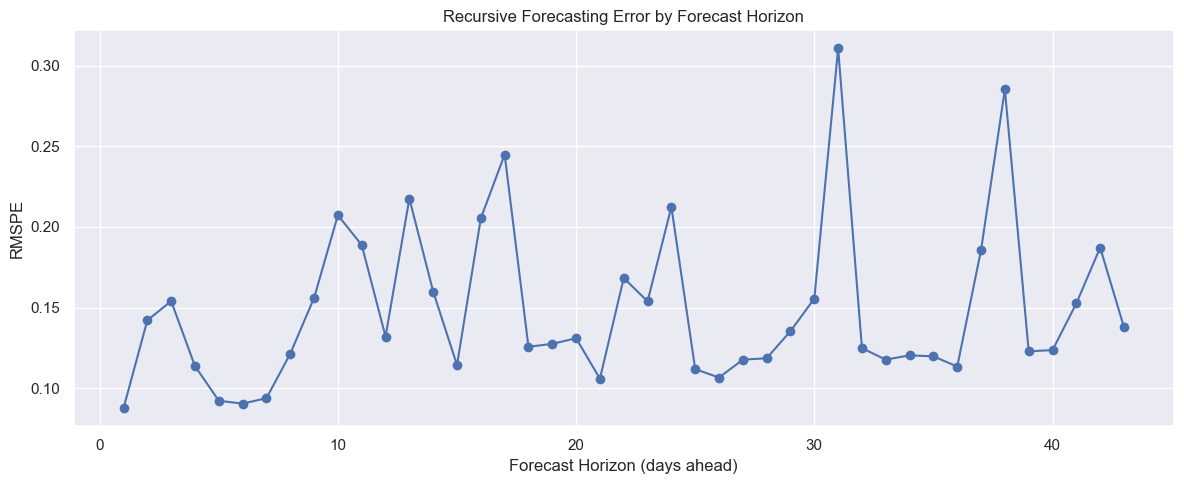

In [72]:
# plot for error by forecast horizon (42 days)

plt.figure(figsize=(12, 5))

plt.plot(horizon_results_df["Forecast_Horizon"], horizon_results_df["RMSPE"], marker="o")

plt.title("Recursive Forecasting Error by Forecast Horizon")
plt.xlabel("Forecast Horizon (days ahead)")
plt.ylabel("RMSPE")

plt.tight_layout()
plt.show()

In [ ]:
# preparing one-step daily results
one_step_plot_df = pd.DataFrame({
    "Date": test_df["Date"],
    "Actual": np.expm1(test_df["Sales_log"]),
    "OneStep_Predicted": np.expm1(y_pred_one_step)
})

test_daily = (one_step_plot_df.groupby("Date")[["Actual", "OneStep_Predicted"]].mean().reset_index())

# preparing recursive daily results
recursive_plot_df = recursive_predictions.copy()
recursive_plot_df["Actual"] = np.expm1(recursive_plot_df["Sales_log"])
recursive_plot_df["Recursive_Predicted"] = np.expm1(recursive_plot_df["Sales_log_pred_recursive"])

daily_recursive = (recursive_plot_df.groupby("Date")[["Recursive_Predicted"]].mean().reset_index())

# merging one-step and recursive results
comparison_recursive = test_daily.merge(daily_recursive, on="Date", how="left")
comparison_recursive["Error_OneStep"] = (comparison_recursive["OneStep_Predicted"] - comparison_recursive["Actual"])
comparison_recursive["Error_Recursive"] = (comparison_recursive["Recursive_Predicted"] - comparison_recursive["Actual"])

comparison_recursive.head()

,Date,Actual,OneStep_Predicted,Recursive_Predicted,Error_OneStep,Error_Recursive
0,2015-06-19,7592.6858,7737.5962,7737.5962,144.9104,144.9104
1,2015-06-20,5736.6795,5287.8101,5293.7251,-448.8695,-442.9544
2,2015-06-21,7807.7812,7439.6401,7413.0000,-368.1411,-394.7812
3,2015-06-22,5881.9910,6052.7041,6004.3882,170.7131,122.3972
4,2015-06-23,5648.4488,5502.7231,5558.2900,-145.7257,-90.1588


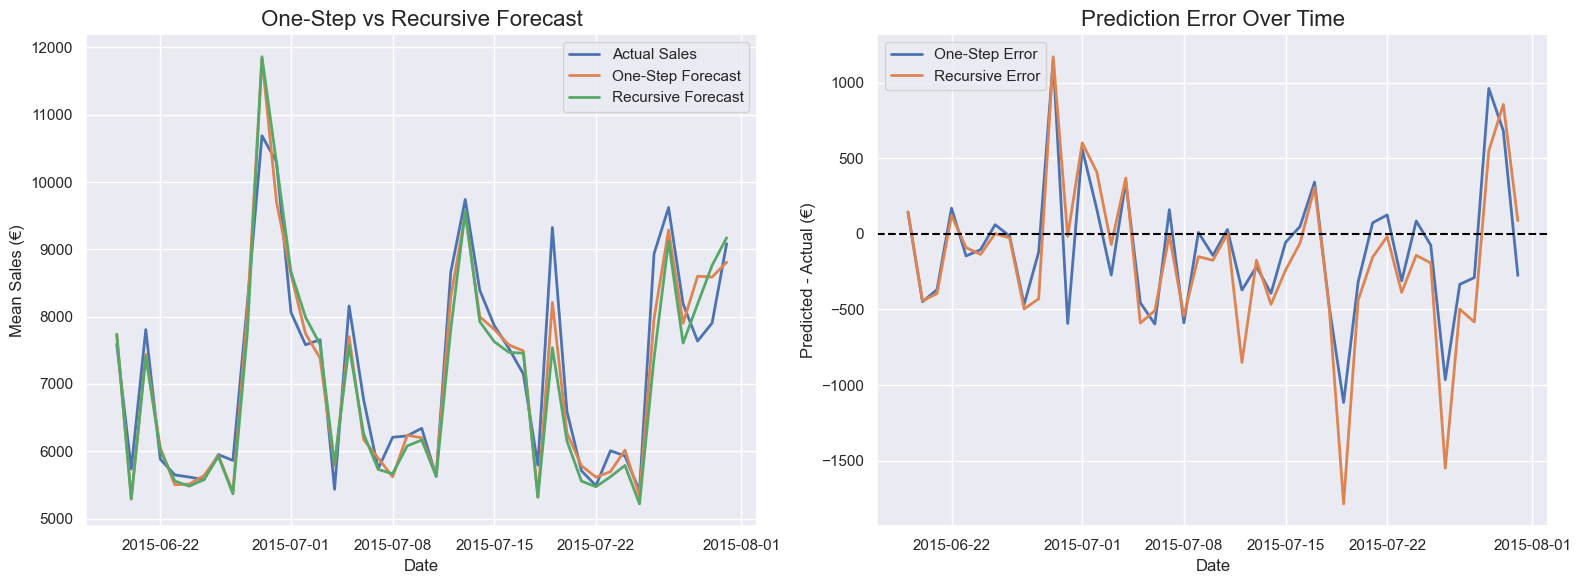

In [80]:
# Actual vs Predicted Over Time (Test Set) - Original XGBoost vs Recursive Forecasting Approach

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left plot: actual vs predicted over time

axes[0].plot(comparison_recursive["Date"], comparison_recursive["Actual"], label="Actual Sales", linewidth=2)

axes[0].plot(comparison_recursive["Date"], comparison_recursive["OneStep_Predicted"], label="One-Step Forecast", linewidth=2)

axes[0].plot(comparison_recursive["Date"], comparison_recursive["Recursive_Predicted"], label="Recursive Forecast", linewidth=2)

axes[0].set_title("One-Step vs Recursive Forecast", fontsize=16)
axes[0].set_xlabel("Date", fontsize=12)
axes[0].set_ylabel("Mean Sales (€)", fontsize=12)
axes[0].legend()

# right plot: prediction error over time

axes[1].plot(comparison_recursive["Date"], comparison_recursive["Error_OneStep"], label="One-Step Error", linewidth=2)

axes[1].plot(comparison_recursive["Date"], comparison_recursive["Error_Recursive"], label="Recursive Error", linewidth=2)

axes[1].axhline(y=0, linestyle="--", color="black")

axes[1].set_title("Prediction Error Over Time", fontsize=16)
axes[1].set_xlabel("Date", fontsize=12)
axes[1].set_ylabel("Predicted - Actual (€)", fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

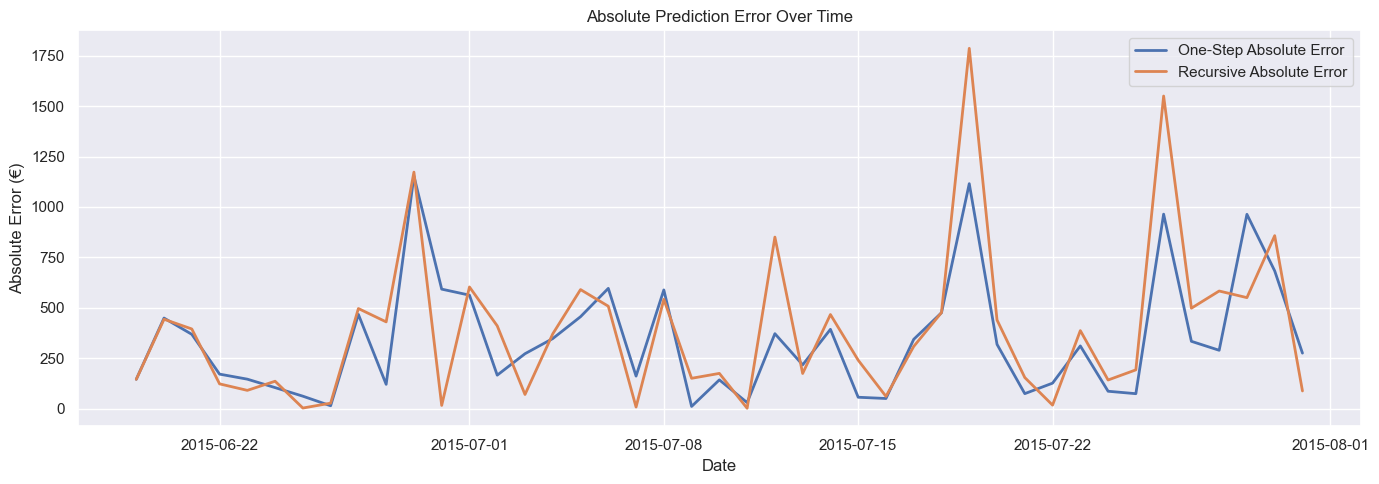

In [ ]:
# absolute prediction error over time - One-Step Error vs Recursive Error 

comparison_recursive["Abs_Error_OneStep"] = np.abs(comparison_recursive["Error_OneStep"])

comparison_recursive["Abs_Error_Recursive"] = np.abs(comparison_recursive["Error_Recursive"])

plt.figure(figsize=(14, 5))

plt.plot(comparison_recursive["Date"], comparison_recursive["Abs_Error_OneStep"], label="One-Step Absolute Error", linewidth=2)

plt.plot(comparison_recursive["Date"], comparison_recursive["Abs_Error_Recursive"], label="Recursive Absolute Error", linewidth=2)

plt.title("Absolute Prediction Error Over Time")
plt.xlabel("Date")
plt.ylabel("Absolute Error (€)")
plt.legend()

plt.tight_layout()
plt.show()

### **Key Findings:**

- The recursive forecasting setup produced **only a moderate decline in accuracy** relative to the one-step (original) approach, indicating that forecast errors do not accumulate excessively over the 42-day horizon.

- These results suggest that the model can be used not only for next-day prediction, but also for **generating longer-term sales forecasts required in real-world planning scenarios**.